# Analysis Results

## Overview

This notebook analyzes the classification results from Notebook 04.

The previous notebook trained several classical machine learning models on HOG features extracted from Canny sketch images. Logistic Regression was selected as the best model based on validation macro F1-score and was then evaluated on the held-out test set.

This notebook focuses on interpreting the results rather than training new models. It reviews the model comparison, analyzes class-level performance, inspects confusion patterns, and prepares visual examples of correct and incorrect predictions.

The goal is to understand not only how well the model performs, but also where and why it makes mistakes.

## Setup and Imports

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sys.path.append("..")

%reload_ext autoreload
%autoreload 2

from src import utils

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded successfully")

Libraries loaded successfully


## Load Saved Results

The saved outputs from Notebook 04 are loaded here.

These files include the validation model comparison table and the final test predictions for the selected Logistic Regression model. The prediction file contains the relative image path, true label, predicted label, and a correctness flag for each test sample.

In [2]:
tables_dir = utils.OUTPUTS_DIR / "tables"

model_comparison_path = tables_dir / "validation_model_comparison.csv"
test_predictions_path = tables_dir / "test_predictions.csv"

model_comparison_df = pd.read_csv(model_comparison_path)
test_predictions_df = pd.read_csv(test_predictions_path)

print(f"Model comparison shape: {model_comparison_df.shape}")
print(f"Test predictions shape: {test_predictions_df.shape}")

Model comparison shape: (4, 3)
Test predictions shape: (375, 4)


In [3]:
model_comparison_df

,model,accuracy,macro_f1
0,Logistic Regression,0.786667,0.787726
1,Random Forest,0.781333,0.781674
2,SVM,0.765333,0.768859
3,KNN,0.474667,0.473720


In [4]:
test_predictions_df.head()

,relative_path,true_label,predicted_label,correct
0,houzz/dressers/Transitional/1623transitional-dressers.jpg,dresser,dresser,True
1,houzz/sofas/Contemporary/189contemporary-sofas.jpg,sofa,sofa,True
2,houzz/tables/Modern/10919modern-coffee-tables.jpg,table,chair,False
3,houzz/tables/Modern/8865modern-side-tables-and-end-tables.jpg,table,table,True
4,houzz/chairs/Contemporary/2685contemporary-recliner-chairs.jpg,chair,chair,True


In [5]:
print("Model comparison columns:")
print(model_comparison_df.columns.tolist())

print("\nTest prediction columns:")
print(test_predictions_df.columns.tolist())

print(f"\nTotal test predictions: {len(test_predictions_df)}")
print(f"Correct predictions: {test_predictions_df['correct'].sum()}")
print(f"Incorrect predictions: {(~test_predictions_df['correct']).sum()}")

Model comparison columns:
['model', 'accuracy', 'macro_f1']

Test prediction columns:
['relative_path', 'true_label', 'predicted_label', 'correct']

Total test predictions: 375
Correct predictions: 295
Incorrect predictions: 80


### Observation

The saved result files were loaded successfully.

The model comparison table contains the validation accuracy and macro F1-score for the four tested classifiers. The test prediction file contains 375 predictions from the held-out test set, including the true label, predicted label, and correctness flag for each sample.

There are **295 correct predictions** and **80 incorrect predictions**. These incorrect cases will be used later in this notebook to inspect typical model errors.

## Review Model Comparison

The validation model comparison from Notebook 04 is reviewed here as the starting point for the analysis.

Logistic Regression was selected as the best model based on validation macro F1-score. Three of the four classifiers performed within a narrow range, while KNN performed notably worse.

In [6]:
model_comparison_df

,model,accuracy,macro_f1
0,Logistic Regression,0.786667,0.787726
1,Random Forest,0.781333,0.781674
2,SVM,0.765333,0.768859
3,KNN,0.474667,0.473720


The same comparison is visualized below for easier interpretation.

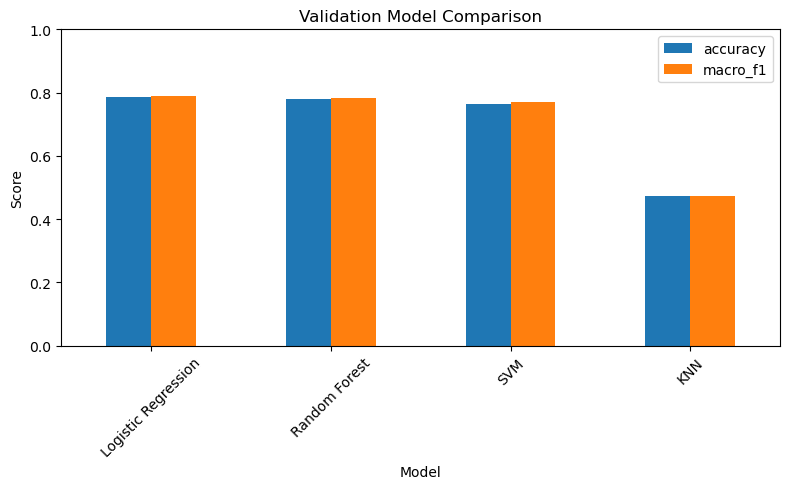

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

model_comparison_df.set_index("model")[["accuracy", "macro_f1"]].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Validation Model Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Observation

The validation comparison confirms that Logistic Regression achieved the strongest result, with a macro F1-score of **0.7877**. Random Forest and SVM were close behind, with macro F1-scores of **0.7817** and **0.7689**.

The small difference between the top three models suggests that the HOG feature representation contains useful class-discriminative shape information that can be learned by several classical ML algorithms.

KNN performed much worse, with a macro F1-score of **0.4737**. This supports the conclusion from Notebook 04 that distance-based classification is less suitable for the high-dimensional HOG feature space used in this project.

## Analyze Final Test Performance

The final test performance of the selected Logistic Regression model is reviewed here.

The test set was not used for model training or model selection, so it provides the final estimate of how well the selected model generalizes to unseen sketch images.

In [9]:
test_accuracy = test_predictions_df["correct"].mean()
test_macro_f1 = 0.7861  # from Notebook 04 final test evaluation

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test macro F1-score: {test_macro_f1:.4f}")
print(f"Correct predictions: {test_predictions_df['correct'].sum()}")
print(f"Incorrect predictions: {(~test_predictions_df['correct']).sum()}")

Test accuracy: 0.7867
Test macro F1-score: 0.7861
Correct predictions: 295
Incorrect predictions: 80


### Observation

The selected Logistic Regression model achieved a final test accuracy of **0.7867** and a test macro F1-score of **0.7861**.

The test score is very close to the validation macro F1-score of **0.7877**, which suggests that the model generalizes consistently and does not show significant overfitting.

Out of 375 test samples, the model correctly classified 295 images and made 80 incorrect predictions.

## Class-Level Performance

The final test result is analyzed per furniture class.

Class-level performance helps identify whether the model performs consistently across all categories or depends mainly on a few easier classes.

In [10]:
class_performance = (
    test_predictions_df
    .groupby("true_label")["correct"]
    .agg(["sum", "count", "mean"])
    .rename(columns={
        "sum": "correct_predictions",
        "count": "total_samples",
        "mean": "class_accuracy"
    })
    .sort_values(by="class_accuracy", ascending=False)
)

class_performance

,correct_predictions,total_samples,class_accuracy
true_label,,,
sofa,64,75,0.853333
dresser,62,75,0.826667
table,59,75,0.786667
chair,56,75,0.746667
bed,54,75,0.720000


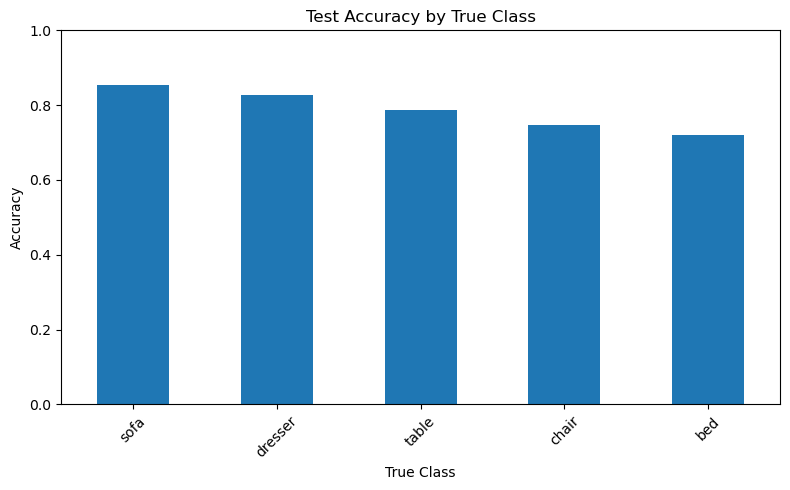

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

class_performance["class_accuracy"].plot(kind="bar", ax=ax)

ax.set_title("Test Accuracy by True Class")
ax.set_xlabel("True Class")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Observation

The class-level accuracy is relatively balanced across the five furniture categories.

`Sofa` performs best, with 64 correct predictions out of 75 test samples. `Dresser` also performs strongly, with 62 correct predictions. These classes likely contain more distinctive contour patterns in the Canny sketch representation.

`Bed` has the lowest class accuracy, with 54 correct predictions out of 75 samples. This is consistent with earlier dataset observations: the `bed` category contains several visually different subtypes, such as platform beds, canopy beds, daybeds, and bunk beds.

Overall, no class collapses completely, which supports the conclusion that the model learns useful shape information across the full five-class dataset.

## Confusion Patterns

Beyond per-class accuracy, it is useful to examine which specific category pairs are confused most often. The confusion matrix shows the full error structure, while a ranked table of the most frequent error pairs highlights where the model struggles most.

In [12]:
wrong_predictions_df = test_predictions_df[
    test_predictions_df["correct"] == False
].copy()

confusion_pairs = (
    wrong_predictions_df
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

confusion_pairs.head(10)

,true_label,predicted_label,count
17,table,dresser,10
7,chair,table,8
2,bed,sofa,7
1,bed,dresser,6
0,bed,chair,5
4,chair,bed,5
8,dresser,bed,5
10,dresser,table,5
16,table,chair,4
6,chair,sofa,4


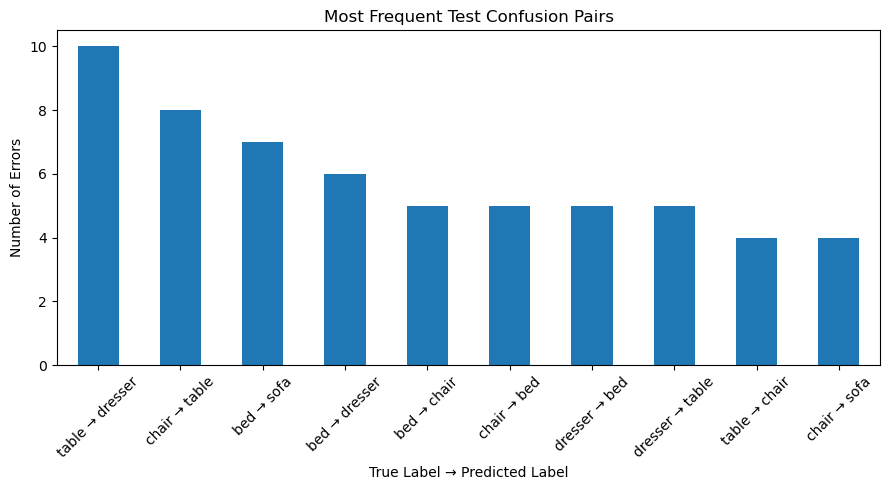

In [13]:
top_confusions = confusion_pairs.head(10).copy()
top_confusions["pair"] = (
    top_confusions["true_label"] + " → " + top_confusions["predicted_label"]
)

fig, ax = plt.subplots(figsize=(9, 5))

top_confusions.set_index("pair")["count"].plot(kind="bar", ax=ax)

ax.set_title("Most Frequent Test Confusion Pairs")
ax.set_xlabel("True Label → Predicted Label")
ax.set_ylabel("Number of Errors")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [14]:
print(f"Total incorrect predictions: {len(wrong_predictions_df)}")
print(f"Error pairs shown in top 10: {top_confusions['count'].sum()}")

Total incorrect predictions: 80
Error pairs shown in top 10: 59


### Observation

The most frequent confusion pair is `table` predicted as `dresser`, with **10** cases. This is consistent with the visual structure of both classes: tables and dressers can both contain rectangular horizontal surfaces, vertical supports, and box-like outlines in the sketch representation.

The next most frequent error is `chair` predicted as `table`, with **8** cases. This may happen when chair sketches emphasize legs and horizontal seat surfaces more than the backrest, making them visually closer to small tables.

The `bed` class appears in several different confusion pairs, including `bed` predicted as `sofa`, `dresser`, and `chair`. This supports the earlier observation that the `bed` category has high intra-class variation and can overlap visually with other furniture categories in contour-based features.

Overall, the errors are not random. They mostly occur between furniture categories that share similar geometric structures in Canny sketch and HOG feature space.

The top 10 confusion pairs cover **59 of the 80** incorrect predictions, or about **74%** of all errors. This shows that most mistakes are concentrated in a small number of repeated and interpretable confusion patterns.

## Wrong Prediction Examples

## Correct Prediction Examples

## Key Findings

## Limitations

## Summary and Next Steps